In [1]:
import cv2
from insightface.app import FaceAnalysis
from matplotlib import pyplot as plt

app = FaceAnalysis()
어떤 모델 쓸지 설정
app.prepare()
-> 실제 모델 다운로드, ONNX 모델 로드, detector 초기화, recognition 초기화

In [2]:
app = FaceAnalysis(
    providers=['CPUExecutionProvider']
)

app.prepare(
    ctx_id=0,
    det_size=(640, 640)
)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\wonbin/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112]

### test.jpg 이미지 읽기

In [10]:
import cv2

img = cv2.imread("../images/test.jpg")

얼굴 검출, landmark 추출, embedding 생성
얼굴 개수 확인

In [11]:
faces = app.get(img)
print("검출된 얼굴 수:", len(faces))

C:\Users\wonbin\Desktop\face-test\venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


검출된 얼굴 수: 6


face.bbox -> [x1,y1,x2,y2] 형태의 얼굴 좌표 반환
- 왼쪽 위(100,50)
- 오른쪽 아래(300,280)
박스라는 의미



In [12]:
for face in faces:
    box = face.bbox.astype(int)
    x1,y1,x2,y2=box
    cv2.rectangle(
        img,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

얼굴 주변에 초록색 사각형 생성

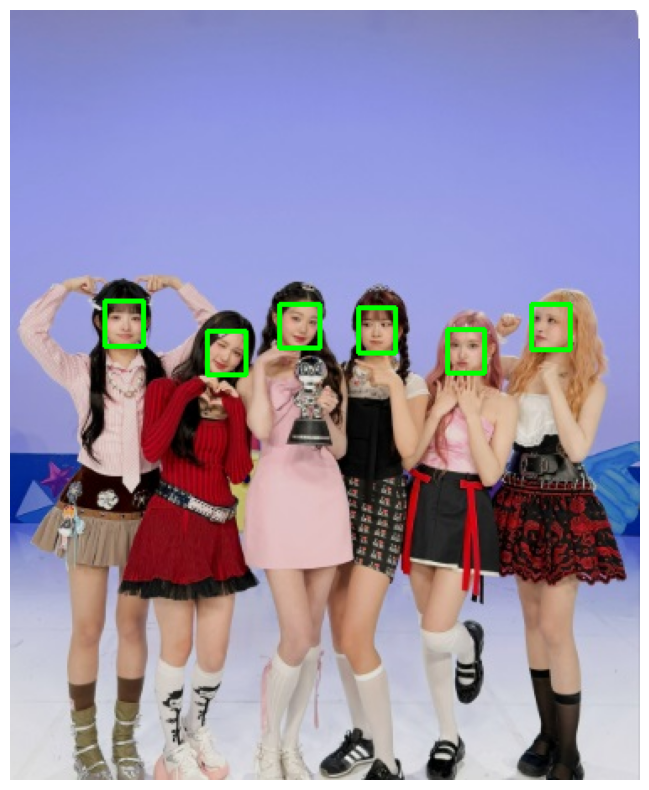

In [13]:
from matplotlib import pyplot as plt
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()